In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-12 13:45:49.065264


# gaussian mixture model

GMM on a subset of the data as analysis strategy for separating signal and noise

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [4]:
base_dir = Path("/home/workspace/projects/drg")
input_dir = os.path.join(base_dir, 'data/h5ad/export_03/')

### Read and process adata

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'adata-scvi-leiden-annotated-all.h5ad'))
adata 
# have to use the version of the dataset that has the transgenes to draw positive and negative signal

AnnData object with n_obs × n_vars = 95966 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1', 'leiden_scVI_1_c

In [6]:
bdata = sc.read_h5ad(os.path.join(input_dir, 'adata-scvi-leiden-annotated-no-transgenes.h5ad'))
bdata # this is the dataset with adata.var subsetted to 475, 5 transgenes witheld

AnnData object with n_obs × n_vars = 95966 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1_nt'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1_nt', 'leiden_sc

In [7]:
adata.X[:5, :5].toarray()

array([[0.       , 5.9971585, 0.       , 0.       , 0.       ],
       [6.7056313, 0.       , 8.537184 , 8.752257 , 0.       ],
       [6.6963024, 0.       , 7.6118517, 9.046559 , 0.       ],
       [0.       , 0.       , 0.       , 9.5951805, 0.       ],
       [0.       , 8.247428 , 0.       , 8.247428 , 0.       ]],
      dtype=float32)

In [8]:
transgenes = ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']

In [9]:
adata.X = adata.layers['counts'].copy()

### view expression of each transgene

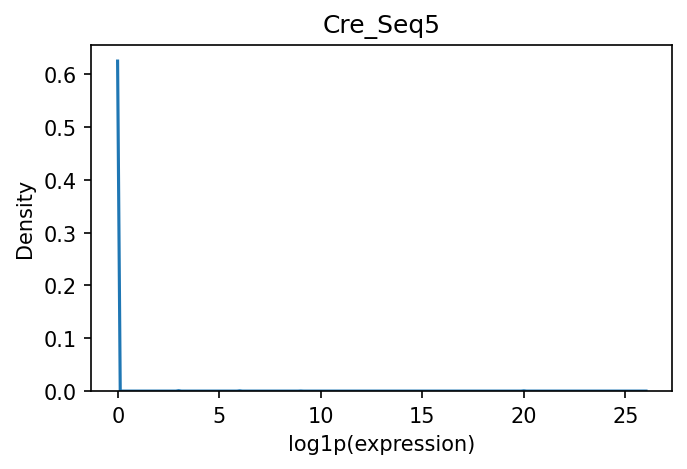

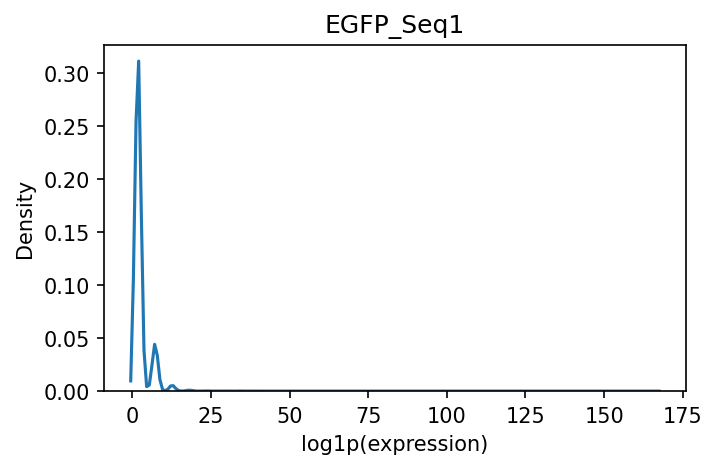

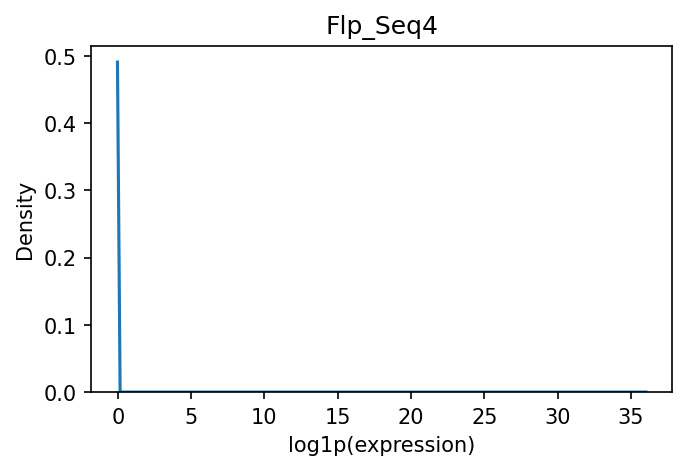

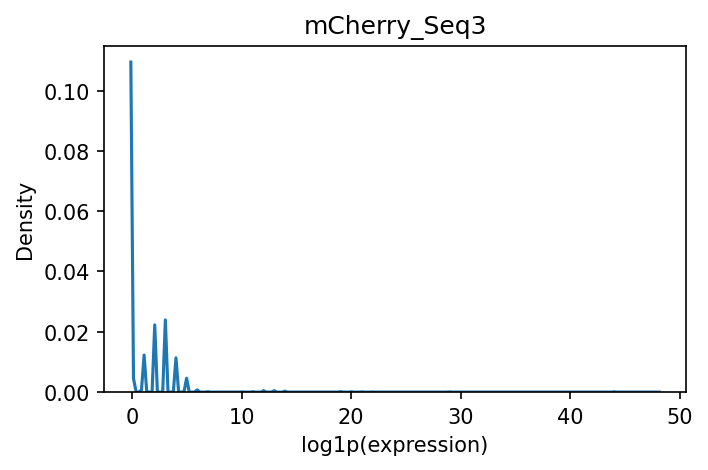

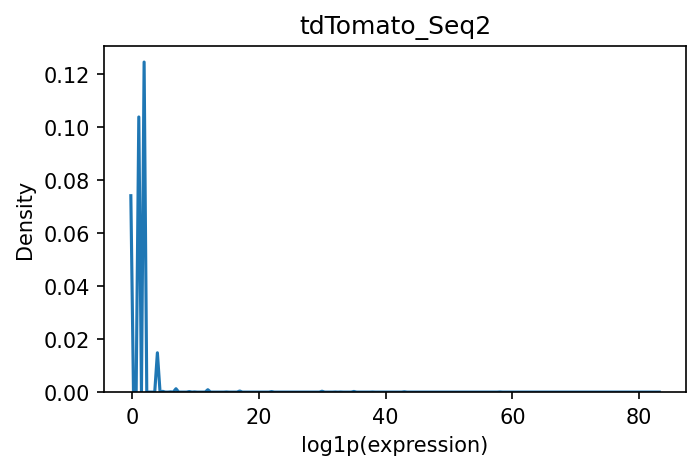

In [10]:
for g in transgenes:
    x = adata[:, g].X
    if hasattr(x, "toarray"): x = x.toarray().ravel()
    else: x = np.ravel(x)
    #x = np.log1p(x)   # log-transform
    
    plt.figure(figsize=(5,3))
    sns.kdeplot(x, bw_adjust=0.5)
    plt.title(g)
    plt.xlabel("log1p(expression)")
    plt.ylabel("Density")
    plt.show()

In [11]:
genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

for g in genes:
    x = to_dense(adata[:, g].X)
    x_log = np.log1p(x).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log)
    probs = gmm.predict_proba(x_log)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high = x[high_mask]

    thr_expr = np.percentile(x_high, within_cluster_q * 100) if x_high.size > 0 else np.expm1(means[high_cluster])
    hi_mask = high_mask & (x > thr_expr)

    adata.obs[f"{g}_hi"] = hi_mask

    # store all useful things for later plotting
    gmm_results[g] = {
        "gmm": gmm,
        "x": x,
        "x_log": x_log,
        "means": means,
        "covars": gmm.covariances_.flatten(),
        "weights": gmm.weights_.flatten(),
        "high_cluster": high_cluster,
        "high_mask": high_mask,
        "thr_expr": thr_expr,
    }

    print(f"{g}: high_cluster_mean={np.expm1(means[high_cluster]):.2f}, "
          f"thr={thr_expr:.2f}, n_hi={hi_mask.sum()} ({100*hi_mask.mean():.4f}%)")

adata.obs['EGFP_tdTomato_dual_hi'] = adata.obs['EGFP_Seq1_hi'] & adata.obs['tdTomato_Seq2_hi']
n_dual = adata.obs['EGFP_tdTomato_dual_hi'].sum()
print(f"\nUltra-strict dual positives: {n_dual}/{adata.n_obs} ({100*n_dual/adata.n_obs:.4f}%)")

EGFP_Seq1: high_cluster_mean=3.79, thr=15.00, n_hi=349 (0.3637%)
tdTomato_Seq2: high_cluster_mean=2.50, thr=17.80, n_hi=42 (0.0438%)

Ultra-strict dual positives: 6/95966 (0.0063%)


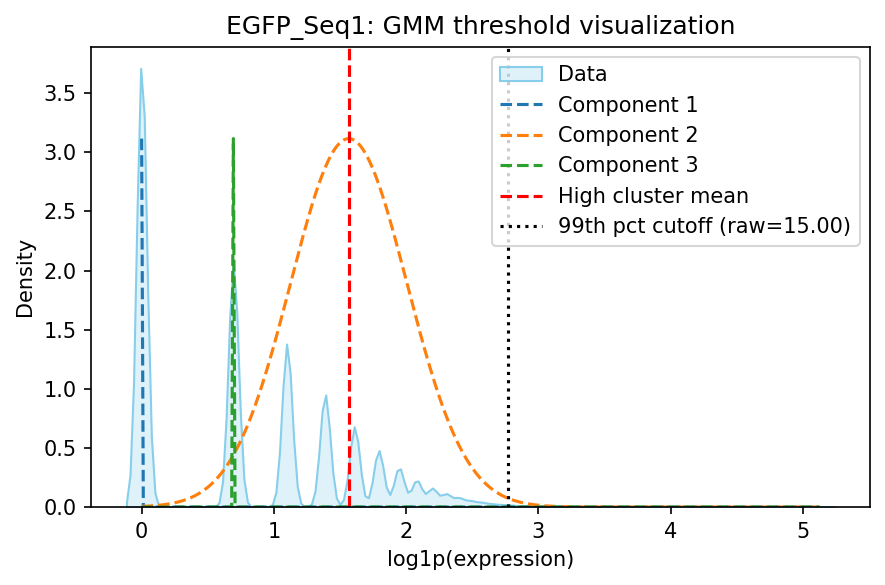

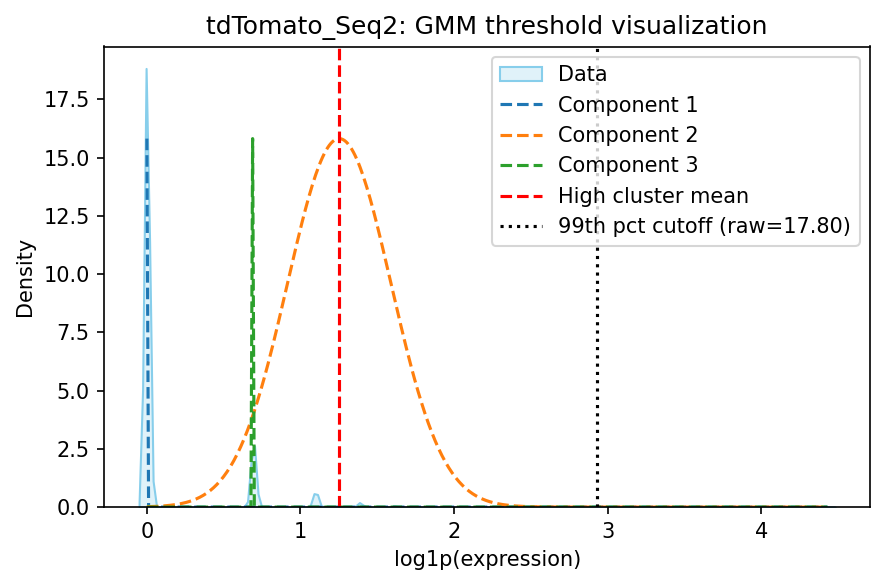

In [12]:
for g, res in gmm_results.items():
    x_log = res["x_log"]
    means = res["means"]
    covars = res["covars"]
    weights = res["weights"]
    high_cluster = res["high_cluster"]
    thr_expr = res["thr_expr"]

    # Convert thresholds for plotting
    mean_log = means[high_cluster]
    thr_log = np.log1p(thr_expr)

    # --- KDE of expression ---
    plt.figure(figsize=(6, 4))
    sns.kdeplot(x_log.ravel(), bw_adjust=0.5, fill=True, color="skyblue", label="Data")

    # --- Overlay Gaussian components ---
    xs = np.linspace(x_log.min(), x_log.max(), 400).reshape(-1, 1)
    total_pdf = np.zeros_like(xs)

    for i, (m, c, w) in enumerate(zip(means, covars, weights)):
        pdf = w * np.exp(-0.5 * ((xs - m) ** 2 / c)) / np.sqrt(2 * np.pi * c)
        total_pdf += pdf
        plt.plot(xs, pdf / pdf.max() * plt.ylim()[1] * 0.8, "--", label=f"Component {i+1}")

    # --- Mark key thresholds ---
    plt.axvline(mean_log, color="red", ls="--", label="High cluster mean")
    plt.axvline(thr_log, color="black", ls=":", label=f"99th pct cutoff (raw={thr_expr:.2f})")

    plt.title(f"{g}: GMM threshold visualization")
    plt.xlabel("log1p(expression)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

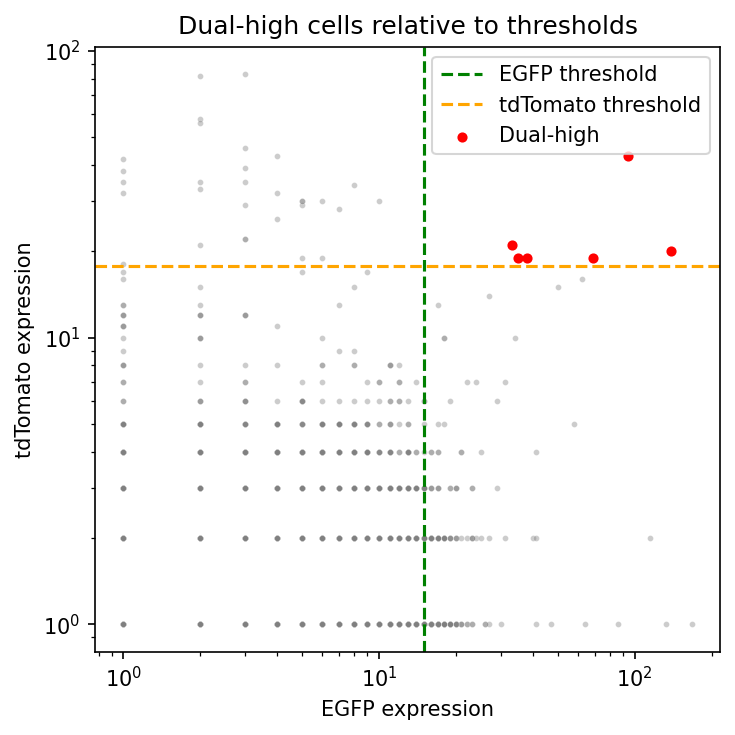

In [13]:
thr_egfp = gmm_results["EGFP_Seq1"]["thr_expr"]
thr_td = gmm_results["tdTomato_Seq2"]["thr_expr"]

# Helper to ensure dense array
def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

x_egfp = to_dense(adata[:, "EGFP_Seq1"].X)
x_td = to_dense(adata[:, "tdTomato_Seq2"].X)
dual = adata.obs['EGFP_tdTomato_dual_hi']

plt.figure(figsize=(5,5))
sns.scatterplot(
    x=x_egfp, y=x_td,
    s=8, alpha=0.4, color="gray"
)

# Add threshold lines
plt.axvline(thr_egfp, color="green", ls="--", label="EGFP threshold")
plt.axhline(thr_td, color="orange", ls="--", label="tdTomato threshold")

# Highlight dual-high cells
plt.scatter(
    x_egfp[dual], x_td[dual],
    s=15, color="red", label="Dual-high"
)

plt.xscale("log"); plt.yscale("log")
plt.xlabel("EGFP expression")
plt.ylabel("tdTomato expression")
plt.title("Dual-high cells relative to thresholds")
plt.legend()
plt.tight_layout()
plt.show()

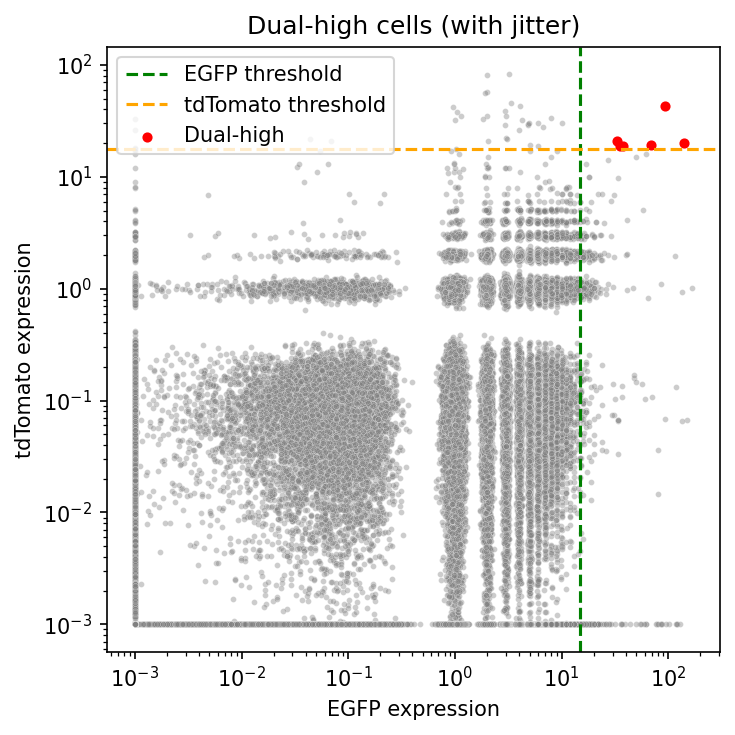

In [15]:
thr_egfp = gmm_results["EGFP_Seq1"]["thr_expr"]
thr_td = gmm_results["tdTomato_Seq2"]["thr_expr"]

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

x_egfp = to_dense(adata[:, "EGFP_Seq1"].X)
x_td = to_dense(adata[:, "tdTomato_Seq2"].X)
dual = adata.obs['EGFP_tdTomato_dual_hi']

# Add small random jitter before plotting
rng = np.random.default_rng(0)
x_egfp_j = x_egfp + rng.normal(scale=0.1, size=x_egfp.shape)
x_td_j   = x_td   + rng.normal(scale=0.1, size=x_td.shape)

# Keep values non-negative (important for log scale)
x_egfp_j = np.clip(x_egfp_j, 1e-3, None)
x_td_j   = np.clip(x_td_j, 1e-3, None)

plt.figure(figsize=(5,5))
sns.scatterplot(
    x=x_egfp_j, y=x_td_j,
    s=8, alpha=0.4, color="gray"
)

plt.axvline(thr_egfp, color="green", ls="--", label="EGFP threshold")
plt.axhline(thr_td, color="orange", ls="--", label="tdTomato threshold")

plt.scatter(
    x_egfp_j[dual], x_td_j[dual],
    s=15, color="red", label="Dual-high"
)

plt.xscale("log"); plt.yscale("log")
plt.xlabel("EGFP expression")
plt.ylabel("tdTomato expression")
plt.title("Dual-high cells (with jitter)")
plt.legend()
plt.tight_layout()
plt.show()

### print barcodes

In [14]:
dual_positive_cells = adata.obs_names[adata.obs['EGFP_tdTomato_dual_hi']]
print("Dual-positive cell barcodes:")
print(list(dual_positive_cells))
print(f"\nTotal: {len(dual_positive_cells)} cells")

Dual-positive cell barcodes:
['bpoikicj-1-0', 'bmjgagok-1-1', 'ijnggkoc-1-1', 'akcoadof-1-3', 'bgmdeeeb-1-3', 'hjjgalia-1-3']

Total: 6 cells


### use barcodes to see wehre they are in bdata

In [26]:
bdata

AnnData object with n_obs × n_vars = 95966 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1_nt'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1_nt', 'leiden_sc

In [19]:
dual_barcodes = ['bpoikicj-1-0', 'bmjgagok-1-1', 'ijnggkoc-1-1', 'akcoadof-1-3', 'bgmdeeeb-1-3', 'hjjgalia-1-3']
dual_in_b = [bc for bc in dual_barcodes if bc in bdata.obs_names]

In [23]:
bdata.obs.loc[dual_in_b, 'leiden_scVI_1_nt']

bpoikicj-1-0    8
bmjgagok-1-1    8
ijnggkoc-1-1    8
akcoadof-1-3    8
bgmdeeeb-1-3    8
hjjgalia-1-3    8
Name: leiden_scVI_1_nt, dtype: category
Categories (24, object): ['0', '1', '2', '3', ..., '20', '21', '22', '23']

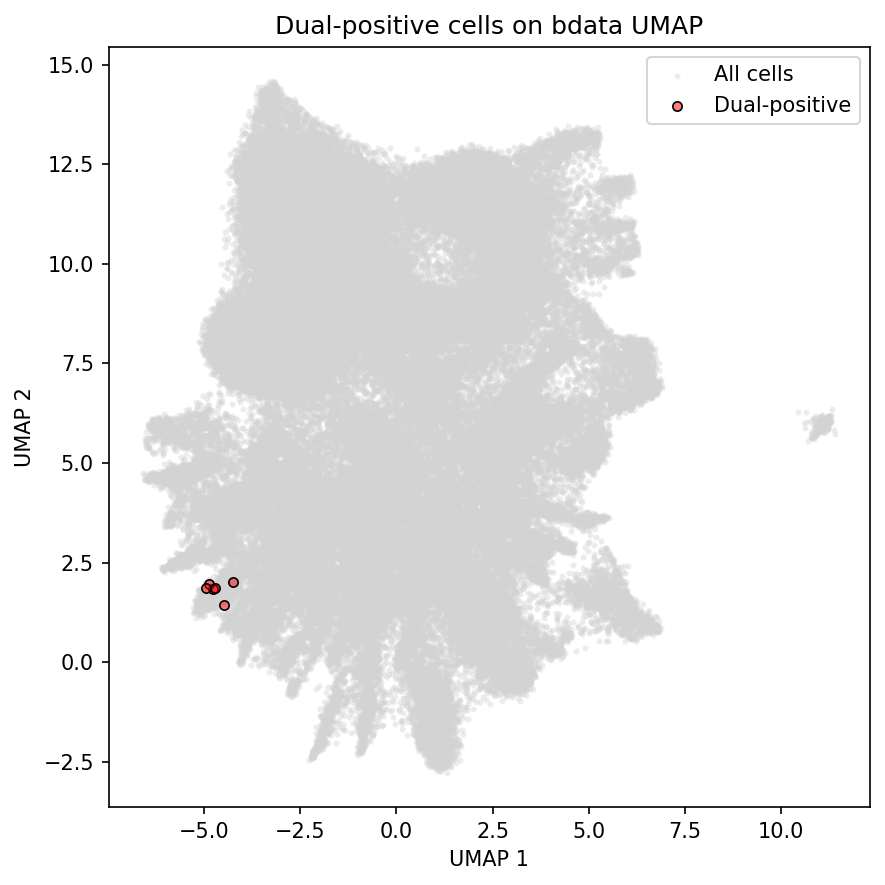

In [30]:
import matplotlib.pyplot as plt

dual_in_b = ['bpoikicj-1-0', 'bmjgagok-1-1', 'ijnggkoc-1-1',
             'akcoadof-1-3', 'bgmdeeeb-1-3', 'hjjgalia-1-3']

dual_in_b = [bc for bc in dual_in_b if bc in bdata.obs_names]
dual_mask = bdata.obs_names.isin(dual_in_b)

plt.figure(figsize=(6,6))

# All cells in gray
plt.scatter(
    bdata.obsm["X_umap"][:, 0],
    bdata.obsm["X_umap"][:, 1],
    s=4, c="lightgray", alpha=0.3, label="All cells"
)

# Dual positives: translucent fill but opaque border
plt.scatter(
    bdata.obsm["X_umap"][dual_mask, 0],
    bdata.obsm["X_umap"][dual_mask, 1],
    s=20,
    facecolors=(1, 0, 0, 0.5),  # RGBA: red with alpha=0.5
    edgecolors="black",         # solid black border
    linewidths=0.8,
    label="Dual-positive"
)

plt.legend()
plt.title("Dual-positive cells on bdata UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()